# 05 — Grey Wolf Optimizer (GWO) Feature Selection

**Goal:** use GWO to search for the feature subset that maximizes classification
performance while minimizing the number of features used. GWO mimics the leadership hierarchy and hunting behavior of grey wolves: the best three solutions (alpha, beta, delta) guide the rest of the pack toward promising regions of the search space.

This notebook follows the exact same pipeline as every other optimizer notebook in
this project (GA / PSO / GWO / WOA) — only the optimizer differs — so results are
directly comparable in `07_Comparison.ipynb`.

**Pipeline:**

```
Initialize wolf pack (candidate feature masks)
        |
        v
  Evaluate fitness (via utils.fitness.fitness)
        |
        v
  Rank wolves -> alpha, beta, delta (3 best solutions)
        |
        v
  Update remaining wolves' positions toward alpha/beta/delta
        |
        v
  Repeat for `epoch` iterations
        |
        v
  Return best feature subset (alpha wolf)
```


In [1]:
import sys
sys.path.append("..")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.preprocessing import load_processed_data
from utils.metrics import evaluate_subset
from utils.fitness import make_fitness_fn

## 1. Load processed data (from notebook 01)

In [2]:
X_train, X_test, y_train, y_test, feature_names = load_processed_data("../datasets")
n_features = X_train.shape[1]
print("Number of features:", n_features)

Number of features: 30


## 2. Define the fitness function

`utils.fitness.fitness` is shared across ALL optimizer notebooks. It combines
classification error with a small penalty on the number of selected features.

In [3]:
fitness_fn = make_fitness_fn(
    X_train, X_test, y_train, y_test,
    classifier="svm",   # keep consistent with the baseline notebook
    alpha=0.99,
)

# mealpy expects fit_func(solution) -> float (to minimize)
def obj_func(solution):
    return fitness_fn(solution)

## 3. Configure and run GWO

Solutions are continuous vectors in [0, 1]^n_features; each dimension is
binarized (`>0.5` -> feature selected) inside the fitness function.

In [6]:
# -------------------------------------------------
# Binary Grey Wolf Optimizer (BGWO)
# -------------------------------------------------

import numpy as np


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def run_bgwo(
    obj_func,
    n_features,
    pop_size=30,
    iterations=50,
):

    # Initialize wolves
    positions = np.random.randint(0, 2, (pop_size, n_features))

    fitness = np.array([obj_func(w) for w in positions])

    order = np.argsort(fitness)

    alpha = positions[order[0]].copy()
    beta = positions[order[1]].copy()
    delta = positions[order[2]].copy()

    alpha_score = fitness[order[0]]

    convergence = []

    for t in range(iterations):

        a = 2 - 2 * (t / iterations)

        for i in range(pop_size):

            new_position = np.zeros(n_features)

            for j in range(n_features):

                # -------- Alpha --------
                r1 = np.random.rand()
                r2 = np.random.rand()

                A1 = 2 * a * r1 - a
                C1 = 2 * r2

                D_alpha = abs(C1 * alpha[j] - positions[i, j])
                X1 = alpha[j] - A1 * D_alpha

                # -------- Beta --------
                r1 = np.random.rand()
                r2 = np.random.rand()

                A2 = 2 * a * r1 - a
                C2 = 2 * r2

                D_beta = abs(C2 * beta[j] - positions[i, j])
                X2 = beta[j] - A2 * D_beta

                # -------- Delta --------
                r1 = np.random.rand()
                r2 = np.random.rand()

                A3 = 2 * a * r1 - a
                C3 = 2 * r2

                D_delta = abs(C3 * delta[j] - positions[i, j])
                X3 = delta[j] - A3 * D_delta

                X = (X1 + X2 + X3) / 3

                prob = sigmoid(X)

                new_position[j] = 1 if np.random.rand() < prob else 0

            # Prevent empty feature subset
            if new_position.sum() == 0:
                new_position[np.random.randint(n_features)] = 1

            positions[i] = new_position

        # Evaluate
        fitness = np.array([obj_func(w) for w in positions])

        order = np.argsort(fitness)

        alpha = positions[order[0]].copy()
        beta = positions[order[1]].copy()
        delta = positions[order[2]].copy()

        alpha_score = fitness[order[0]]

        convergence.append(alpha_score)

    return alpha, alpha_score, convergence

In [8]:
ITERATIONS = 50
POP_SIZE = 30

start_time = time.time()

best_position, best_fitness, convergence_curve = run_bgwo(
    obj_func=fitness_fn,
    n_features=n_features,
    pop_size=POP_SIZE,
    iterations=ITERATIONS
)

runtime = time.time() - start_time

print(f"Best fitness: {best_fitness:.6f}")
print(f"Runtime: {runtime:.2f} seconds")

Best fitness: 0.024035
Runtime: 42.50 seconds


## 4. Extract convergence curve

Saved for the comparison plots in `07_Comparison.ipynb`.

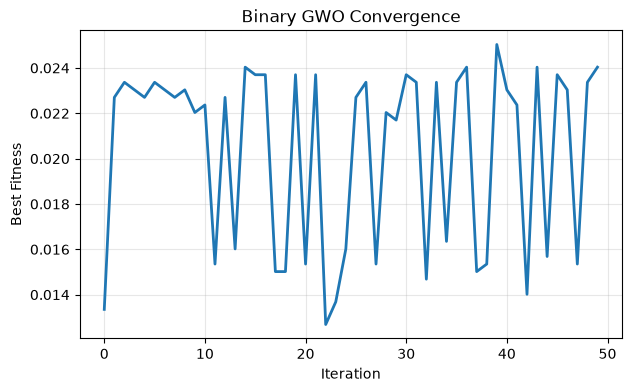

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(convergence_curve, linewidth=2)

plt.xlabel("Iteration")
plt.ylabel("Best Fitness")
plt.title("Binary GWO Convergence")

plt.grid(alpha=0.3)
plt.show()

## 5. Evaluate the best feature subset

Using the exact same `evaluate_subset()` function as the baseline notebook.

In [10]:
best_mask = best_position.astype(int)

selected_features = [
    f for f, m in zip(feature_names, best_mask)
    if m == 1
]

print(f"BGWO selected {best_mask.sum()} / {n_features} features:")
print(selected_features)

results = evaluate_subset(
    best_mask,
    X_train,
    X_test,
    y_train,
    y_test,
    classifier="svm"
)

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc", "n_features"]:
    print(f"{metric}: {results[metric]}")

BGWO selected 20 / 30 features:
['mean radius', 'mean texture', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'texture error', 'perimeter error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst smoothness', 'worst compactness', 'worst symmetry', 'worst fractal dimension']
accuracy: 0.9824561403508771
precision: 0.9861111111111112
recall: 0.9861111111111112
f1: 0.9861111111111112
roc_auc: 0.9963624338624338
n_features: 20


## 6. Save results

Saved to `../results/gwo_results.csv` and
`../results/gwo_convergence.npy` for `07_Comparison.ipynb`.

In [11]:
import os
os.makedirs("../results", exist_ok=True)

results_df = pd.DataFrame([{
    "Algorithm": "GWO",
    "Accuracy": results["accuracy"],
    "Precision": results["precision"],
    "Recall": results["recall"],
    "F1": results["f1"],
    "ROC_AUC": results["roc_auc"],
    "Features": results["n_features"],
    "Runtime": runtime,
}])

results_df.to_csv("../results/gwo_results.csv", index=False)
np.save("../results/gwo_convergence.npy", np.array(convergence_curve))
np.save("../results/gwo_mask.npy", best_mask)

results_df

,Algorithm,Accuracy,Precision,Recall,F1,ROC_AUC,Features,Runtime
0,GWO,0.982456,0.986111,0.986111,0.986111,0.996362,20,42.502787


## Next step

Run the remaining optimizer notebooks (any not yet run), then open
`07_Comparison.ipynb` to compare GWO against the baseline and the other
metaheuristics side by side.